
## 01MIAR - Actividad Video Valenbici

## NumPy y Pandas

### Objetivos:
- Aplicar diferentes técnicas de tratamiento de estructuras numéricas con Numpy y datos estructurados con Pandas.

### Instrucciones:
- Mantener una estructura limpia, comentando código y secuenciando los apartados con el código correspondiente que resuelva la actividad.
- Como criterio de evaluación se tendrá en cuenta el resultado, la consecución del mismo, estilo, comentarios y adecuación. Siempre será tenido en cuenta cualquier detalle técnico avanzado o no visto en clase relacionado con el tema (explicar el porqué y usabilidad).
- No está permitido compartir los resultados ni el código en ninguno de los foros.
- Revisar los temas 3 y 4, así como las sesiones sobre Numpy y Pandas para aplicar dichos contenidos.
- Proponer las respuestas en las celdas a dicho efecto en cada punto, si se necesitan más celdas añadirlas en su sitio correspondiente
- Mostrar de manera clara la respuesta a las preguntas, mediante código

### Entrega:
- Este mismo notebook con las respuetas

### Evaluación
- Esta actividad corresponde con el 10% de la nota final de la asignatura.

### Fecha Realización
- Convocatoria 1 - 19/05/2023 al 21/05/2023 hasta las 23:59 UTC+2

#### Descripción
El conjunto de datos "valenbici.db" (fichero disponible adjunto a la actividad) proviene de una descarga de datos del servicio web de la empresa municipal Valenbici, dedicada al alquiler de bicicletas en Valencia.

Los datos recabados de este servicio web son de mediciones cada 10 minutos de las estaciones:

https://valencia.opendatasoft.com/explore/dataset/valenbisi-disponibilitat-valenbisi-dsiponibilidad/information/

Cada estación está compuesta por un número variable de bornetas (total) donde se pueden anclar las bicicletas. Los datos obtenidos de cada estación (registros) refleja el número de bornetas libres (free) y el número de bicicletas disponibles (available).

#### Columnas para trabajar:
- number: id de la estación
- total: número total de bornetas
- updated (updated_at en origen): timestamp del estado en de bicis en la estación
- available: número de bicis disponibles

In [3]:
# Your impots here!!!

In [4]:
import pandas as pd

## 01
Carga de datos de csv (estaciones_bici.csv) en un DataFrame y exploración de datos.

La primera columna del fichero debe aparecer como índice del DataFrame.
> Nota: los datos y la libreta de jupyter tienen que estar en la misma carpeta


In [5]:
# Your answer here!!!

In [6]:
df = pd.read_csv('estaciones_bici.csv', engine='python', 
                  delimiter='|', index_col=0, )
print(df.shape)
df.head()

(222180, 9)


,updated,address,number,available,lat,lon,total,open,free
72967,2023-05-04 16:20:06,Peris y Valero - Cuba,39,5,39.457854,-0.373931,19,T,14
94523,2023-05-04 16:20:06,Pintor Luis Arcas - Inst. Obrero Valenciano,46,4,39.455509,-0.358787,20,T,16
193949,2023-05-04 16:20:06,Alfonso el Magnánimo - Nave,13,15,39.472062,-0.370874,24,T,9
30541,2023-05-04 16:20:06,Angel Guimerá - Juan Llorens,22,4,39.469787,-0.388353,15,T,11
63530,2023-05-04 16:20:06,Fernando el Católico - Cuenca,24,7,39.469077,-0.384027,20,T,11


## 02
Calcule la media de la columna "available" y tenga como resultado un dataframe con "address", "number" y la media calculada por estación.

Sobre el resultado anterior, **muestre** un listado, ordenado de mayor a menor, de las estaciones que tienen una media de la columna "available" igual o superior a 15.

**Imprima** el número de registros que tiene el resultado final.

In [7]:
# Your answer here!!!

In [8]:
# Entendiendo que entre number y address existe una relación 1:1
df2 = df.groupby(by="number").agg({
        "address":"max",
        "number":"max",
        "available": "mean"
        })

mask = df2["available"] >= 15
df2 = df2.loc[mask, :]
df2.sort_values(by="available", ascending=False, inplace=True)
display(df2)
print(df2.shape[0])

,address,number,available
number,,,
101,Marino Blas de Lezo (estación Cabañal Adif),101,22.859627
93,Blasco Ibañez - Poeta Durán Tortajada,93,21.423602
124,Azagador de Alboraya - Dolores Marqués,124,21.042236
112,Manuel Broseta i Pont - Naranjos,112,18.585093
69,Av. Puerto - Serrería,69,17.494410
180,Doctor Waksman - Nieves,180,17.444720
110,UPV Trinquet,110,17.176398
192,Cra. Malilla - Oltá,192,16.731677
179,Av. de la Plata - Zapadores,179,16.714286


14


## 03
Muestre solamente el número de estación y dirección de la septima estación con la media más baja de bicis disponibles (columna "available")

In [9]:
# Your answer here!!!

In [10]:
df2.sort_values(by="available", ascending=True).iloc[6, [0, 1]].values

array(['Cra. Malilla - Oltá', 192], dtype=object)

## 04
Seleccione la estación resultado del anterior apartado y establezca como índice la columna "updated". 

Ordene el dataframe de forma ascendente y muestre las tres primeras filas.

Pista, es necesario cambiar el índice a uno tipo fecha.

In [11]:
# Your answer here!!!

In [12]:
mask = df["number"] == 192
df3 = df.loc[mask].copy()
df3["updated"] = pd.to_datetime(df3['updated'], format='%Y-%m-%d %H:%M:%S')
df3.set_index("updated", drop=True, inplace=True)
df3.sort_index(ascending=True, inplace=True)
df3.head(3)

,address,number,available,lat,lon,total,open,free
updated,,,,,,,,
2023-05-04 16:20:06,Cra. Malilla - Oltá,192,16,39.452637,-0.378714,20,T,4
2023-05-04 16:29:13,Cra. Malilla - Oltá,192,15,39.452637,-0.378714,20,T,5
2023-05-04 16:39:47,Cra. Malilla - Oltá,192,16,39.452637,-0.378714,20,T,4


## 05

Realizar gráfica de tipo línea, sobre las bicis disponibles (available) con el dataframe resultado del anterior apartado.

<Axes: xlabel='updated'>

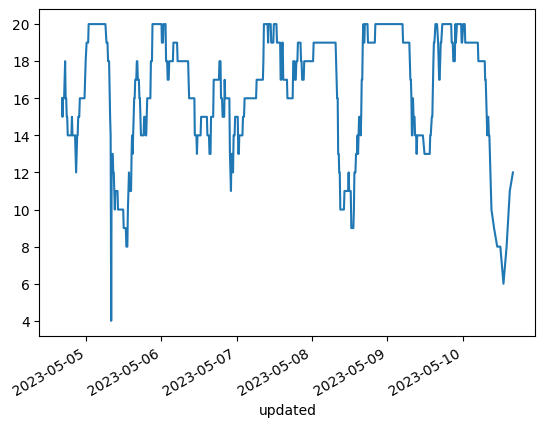

In [13]:
df3["available"].plot(kind="line")